# ANF faithfulness auditor — file-based

Notebook version of the command-line tools (`run.py` + `coverage.py`): point
it at **any two files on disk** — the original narrative and the ANF
reconstruction — and it runs the complete audit: extraction → coverage-gap
check → alignment → ledger → HTML report. Accepts real `.docx`, plain text
with any extension, and fails with a clear message on spreadsheets or
legacy `.doc`.

Edit the two paths in the next cell, then *Run All*.

This notebook compares an **original clinical narrative** with a **narrative
reconstructed from ANF (Analysis Normal Form) statements** — at the level of
atomic clinical facts, not words. It answers four questions:

- which facts **survived** the round trip intact,
- which were **omitted**,
- which were **invented** (unsupported by the source),
- which were **corrupted** — negation flips, laterality flips, value changes,
  or performed-vs-requested confusion.

The pipeline mirrors ANF's own *Clinical Element Isolation* principle: the
unit of comparison is one atomic clinical statement
*(concept, laterality, polarity, value, status)*.

**Pipeline:** extraction → concept normalization (lexicon) → **coverage-gap
check** → bipartite alignment → verdict classification → audit ledger. Each stage sits behind a
swappable interface; the closing section lists the production swap points
(LLM extraction, SapBERT→SNOMED linking, NLI entailment).



In [1]:
# --- 1. Point these at your two files (Windows raw strings are fine) ---
SOURCE_PATH = r"C:\Users\kerry\OneDrive\Thesis\Written Thesis\Ch. 2 ANF Eye Exam\ANF\Agent ANF to Narrative\OE_CE Exams\Clinical_Narrative_ANF_Example_5.docx"              
# original narrative
RECON_PATH  = r"C:\Users\kerry\OneDrive\Thesis\Written Thesis\Ch. 2 ANF Eye Exam\ANF\Agent ANF to Narrative\CE_CE Exams\Clinical_Narrative_C_ANF_Example_5.docx"  
# ANF reconstruction

#Source is now the narrative that agent made off of human ANF excel

import zipfile
try:
    from docx import Document
    from docx.opc.exceptions import PackageNotFoundError
except ModuleNotFoundError:
    raise ModuleNotFoundError("python-docx missing - run: %pip install python-docx")

def docx_to_text(path):
    doc = Document(path)
    parts = [p.text for p in doc.paragraphs if p.text.strip()]
    for table in doc.tables:                        # tables too, just in case
        for row in table.rows:
            parts.append("\t".join(c.text.strip() for c in row.cells))
    return "\n".join(parts)

def load_text(path):
    head = open(path, "rb").read(8)
    if head.startswith(b"PK\x03\x04"):              # zip-based Office file
        try:
            return docx_to_text(path)
        except (PackageNotFoundError, KeyError, ValueError):
            kind = zipfile.ZipFile(path).namelist()[0].split("/")[0]
            raise ValueError(f"{path} is an Office package but not Word "
                             f"(contains {kind!r} - likely .xlsx/.pptx)")
    if head.startswith(b"\xd0\xcf\x11\xe0"):        # legacy binary .doc
        raise ValueError(f"{path} is a legacy .doc - re-save as .docx first")
    raw = open(path, "rb").read()                   # plain text
    try:
        return raw.decode("utf-8")
    except UnicodeDecodeError:
        return raw.decode("cp1252")

SOURCE_TEXT = load_text(SOURCE_PATH)
RECON_TEXT  = load_text(RECON_PATH)
print(f"source: {len(SOURCE_TEXT):,} chars   reconstruction: {len(RECON_TEXT):,} chars")

source: 4,048 chars   reconstruction: 9,371 chars


## 1 · Concept lexicon (normalization layer)

Each concept declares a canonical key (standing in for a SNOMED/LOINC/RxNorm
link), synonym patterns, a clinical category, how to read an attached number
(`acuity`, `mmhg`, `grade`, `µm`, `dB`, `Δ`, …), and whether the concept
takes laterality (`lateral=False` pins systemic facts to NA).

**The lexicon is a domain asset, built once and reused for every
comparison** — it is not rebuilt per pair. This one covers the full
ophthalmic domain of the Example 1 and O-series cases: glaucoma work-ups
(RNFL sectors, GPA, HVF indices, gonioscopy, pachymetry), pediatric
strabismus/amblyopia, ocular trauma, uveitis/Behçet, ROP/neovascular
glaucoma, and orthokeratology fitting. In production it is replaced by an
entity linker; the pipeline interfaces don't change.

In [2]:
CONCEPTS = [
    # ---- demographics / systemic history -------------------------------
    dict(key="age", name="Chronological age", category="history",
         patterns=[r"\b(\d{1,3})[- ]year[- ]old\b"], value_kind="years"),
    dict(key="male", name="Male sex", category="history",
         patterns=[r"\bmale\b", r"\bman\b"], value_kind="none"),
    dict(key="diabetes", name="Type 2 diabetes mellitus", category="history",
         patterns=[r"type 2 diabetes", r"\bdiabetes mellitus\b", r"\bdiabetic man\b"], value_kind="none"),
    dict(key="hba1c", name="HbA1c", category="history",
         patterns=[r"hba1c"], value_kind="percent"),
    dict(key="hypertension", name="Hypertension", category="history",
         patterns=[r"hypertension", r"hypertensive"], value_kind="none"),
    dict(key="diabetic_retinopathy", name="Diabetic retinopathy", category="history",
         patterns=[r"diabetic retinopathy"], value_kind="none"),
    dict(key="neuropathy", name="Neuropathy", category="history",
         patterns=[r"\bneuropathy\b"], value_kind="none"),
    dict(key="nephropathy", name="Nephropathy", category="history",
         patterns=[r"\bnephropathy\b"], value_kind="none"),
    dict(key="tobacco", name="Tobacco use", category="history",
         patterns=[r"\btobacco\b", r"non[- ]smoker", r"\bsmok"], value_kind="none"),
    dict(key="alcohol", name="Alcohol use", category="history",
         patterns=[r"\balcohol\b", r"occasional drinker"], value_kind="none"),
    dict(key="myopia", name="Myopia", category="history",
         patterns=[r"\bmyopia\b"], value_kind="none"),
    dict(key="presbyopia", name="Presbyopia", category="history",
         patterns=[r"\bpresbyopia\b"], value_kind="none"),
    dict(key="cataract_surgery", name="Cataract surgery", category="history",
         patterns=[r"cataract (?:surgery|extraction)", r"phacoemulsification"], value_kind="none"),
    dict(key="iol", name="Intraocular lens implant", category="history",
         patterns=[r"intraocular lens", r"\bpc-?iol\b", r"\biol\b"], value_kind="none"),
    dict(key="trauma", name="Ocular trauma", category="history",
         patterns=[r"\btrauma\b", r"\binjur(?:y|ies|ed)\b", r"struck by"], value_kind="none"),
    dict(key="fever", name="Fever", category="symptom",
         patterns=[r"\bfever\b"], value_kind="none"),
    dict(key="chills", name="Chills", category="symptom",
         patterns=[r"\bchills\b"], value_kind="none"),

    # ---- presenting symptoms -------------------------------------------
    dict(key="eye_pain", name="Eye pain", category="symptom",
         patterns=[r"\beye pain\b", r"deep-eye pain", r"pain in the left eye",
                   r"pain in the right eye", r"ocular pain"], value_kind="none"),
    dict(key="pain_scale", name="Pain scale (0-10)", category="symptom",
         patterns=[r"rated \d{1,2}/10", r"\d{1,2}/10\b"], value_kind="scale10"),
    dict(key="decreased_vision", name="Decreased / blurred vision", category="symptom",
         patterns=[r"decreased vision", r"blurr", r"foggy", r"\bfuzzy\b"], value_kind="none"),
    dict(key="floaters", name="Floaters", category="symptom",
         patterns=[r"\bfloaters?\b"], value_kind="none"),
    dict(key="photophobia", name="Photophobia / light sensitivity", category="symptom",
         patterns=[r"photophobia", r"bright lights exacerbate"], value_kind="none"),

    # ---- medications ----------------------------------------------------
    dict(key="metformin", name="Metformin", category="medication",
         patterns=[r"metformin"], value_kind="none"),
    dict(key="lisinopril", name="Lisinopril", category="medication",
         patterns=[r"lisinopril"], value_kind="none"),
    dict(key="pred_acetate", name="Prednisolone acetate 1%", category="medication",
         patterns=[r"prednisolone acetate"], value_kind="none"),
    dict(key="polytrim", name="Polytrim", category="medication",
         patterns=[r"polytrim"], value_kind="none"),
    dict(key="nkda", name="Drug allergies", category="history",
         patterns=[r"no[- ]known[- ]drug[- ]allerg", r"allergies:?\s*none", r"drug allerg"], value_kind="none"),

    # ---- examination ----------------------------------------------------
    dict(key="visual_acuity", name="Visual acuity", category="exam",
         patterns=[r"visual acuity", r"\b20/\d+\b", r"logmar",
                   r"(?:near|distance) acuity"], value_kind="acuity"),
    dict(key="iop", name="Intraocular pressure", category="exam",
         patterns=[r"intraocular pressure", r"\btonopen\b", r"\biop\b", r"\d+\s*mmhg"], value_kind="mmhg"),
    dict(key="pupils_perrl", name="Pupils equal, round, reactive", category="exam",
         patterns=[r"pupils? (?:were )?equal, round,? (?:and )?reactive",
                   r"equal, round, reactive", r"pupil (?:was )?round",
                   r"pupil (?:was )?reactive", r"reactive to light"], value_kind="none"),
    dict(key="pupil_sluggish", name="Sluggish pupil", category="exam",
         patterns=[r"sluggish"], value_kind="none"),
    dict(key="apd", name="Afferent pupillary defect", category="exam",
         patterns=[r"afferent[- ]pupillary[- ]defect", r"\bapd\b"], value_kind="none"),
    dict(key="motility", name="Extraocular motility", category="exam",
         patterns=[r"extraocular motility", r"ocular motility", r"motility"], value_kind="none"),
    dict(key="nystagmus", name="Nystagmus", category="exam",
         patterns=[r"nystagmus"], value_kind="none"),
    dict(key="visual_fields", name="Visual fields (confrontation)", category="exam",
         patterns=[r"visual fields?"], value_kind="none"),
    dict(key="orbit_normal", name="Orbital structures", category="exam",
         patterns=[r"orbital structures"], value_kind="none"),
    dict(key="lids_lashes", name="Eyelids / lashes", category="exam",
         patterns=[r"lids/lashes", r"eyelids and eyelashes", r"\beyelids?\b"], value_kind="none"),
    dict(key="hyperemia", name="Conjunctival hyperemia / injection", category="exam",
         patterns=[r"hyperemia", r"\binjection\b"], value_kind="grade"),
    dict(key="corneal_edema", name="Corneal edema", category="exam",
         patterns=[r"microcystic edema", r"corneal edema", r"cornea .*not clear",
                   r"not clear in both eyes"], value_kind="none"),
    dict(key="kp", name="Keratic precipitates", category="exam",
         patterns=[r"keratic precipitates"], value_kind="none"),
    dict(key="fibrin", name="Fibrin strands at incision", category="exam",
         patterns=[r"fibrin strands?"], value_kind="none"),
    dict(key="wound_leak", name="Wound leak (Seidel)", category="exam",
         patterns=[r"wound leak", r"seidel"], value_kind="none"),
    dict(key="ac_deep", name="Anterior chamber depth (deep)", category="exam",
         patterns=[r"anterior chambers?(?: of the eye)?(?: was| were|:)? deep",
                   r"chamber:? deep", r"deep ou\b", r"chambers? (?:was |were )?deep"], value_kind="none"),
    dict(key="ac_cells", name="Anterior chamber cells", category="exam",
         patterns=[r"\bcells\b(?! and flare were)", r"\d\+ cells", r"cells were present"], value_kind="grade"),
    dict(key="ac_flare", name="Anterior chamber flare", category="exam",
         patterns=[r"\bflare\b"], value_kind="grade"),
    dict(key="hypopyon", name="Hypopyon", category="exam",
         patterns=[r"hypopyon"], value_kind="mm"),
    dict(key="iris", name="Iris appearance", category="exam",
         patterns=[r"\biris\b", r"\birides\b"], value_kind="none"),
    dict(key="lens_status", name="Lens / IOL status on exam", category="exam",
         patterns=[r"lens:\s", r"iol in place"], value_kind="none"),
    dict(key="vitreous_haze", name="Vitreous haze / hazy vitreous view", category="exam",
         patterns=[r"vitreous haze", r"vitreous:? hazy", r"anterior vitreous: hazy",
                   r"hazy view os"], value_kind="none"),
    dict(key="fundus_view_hazy", name="Hazy fundus view / limited evaluation", category="exam",
         patterns=[r"view is very hazy", r"poorly visualized", r"evaluation limited"], value_kind="none"),
    dict(key="fundus_normal", name="Fundus appearance", category="exam",
         patterns=[r"fundus was documented as normal", r"clear media", r"normal macula",
                   r"sharp disc margins", r"fundus (?:was )?normal", r"fundus[- ]normal"], value_kind="none"),
    dict(key="cdr", name="Cup-to-disc ratio", category="exam",
         patterns=[r"cup-to-disc", r"\bcdr\b"], value_kind="ratio"),
    dict(key="retina_attached", name="Retina attached", category="exam",
         patterns=[r"retina appears attached"], value_kind="none"),
    dict(key="vessels_normal", name="Retinal vessels", category="exam",
         patterns=[r"normal vessels", r"vessels and peripheral retina"], value_kind="none"),

    # ---- diagnosis ------------------------------------------------------
    dict(key="endophthalmitis", name="Acute postoperative endophthalmitis", category="diagnosis",
         patterns=[r"endophthalmitis"], value_kind="none"),
    dict(key="dd_sterile", name="DDx: sterile inflammation", category="diagnosis",
         patterns=[r"sterile inflammation", r"sterile \(non-infectious\)"], value_kind="none"),
    dict(key="dd_panuveitis", name="DDx: panuveitis", category="diagnosis",
         patterns=[r"panuveitis"], value_kind="none"),
    dict(key="dd_lens_fragment", name="DDx: retained lens fragment", category="diagnosis",
         patterns=[r"retained lens fragment"], value_kind="none"),

    # ---- plan -----------------------------------------------------------
    dict(key="vitreous_tap", name="Vitreous/aqueous tap for culture", category="plan",
         patterns=[r"vitreous tap", r"vitreous and/or aqueous samples",
                   r"aspiration of the vitreous", r"tap and inject", r"\(tap\)"], value_kind="none"),
    dict(key="intravitreal_abx", name="Intravitreal antibiotics", category="plan",
         patterns=[r"intravitreal (?:broad-spectrum )?antibiotics"], value_kind="none"),
    dict(key="bscan", name="Ocular ultrasound (B-scan)", category="plan",
         patterns=[r"b-scan", r"ocular ultrasound"], value_kind="none"),
    dict(key="continue_topicals", name="Continue topical therapy", category="plan",
         patterns=[r"continue.*topical"], value_kind="none"),
    dict(key="close_monitoring", name="Close follow-up / monitoring", category="plan",
         patterns=[r"follow closely", r"daily or more frequent monitoring"], value_kind="none"),
    dict(key="education", name="Patient education / counseling", category="plan",
         patterns=[r"patient education", r"counsel(?:ed|ing)? (?:the )?patient",
                   r"counsel patient"], value_kind="none"),
]

# ======================================================================
# O-series extension — glaucoma work-ups, trial screening, pediatric
# strabismus/amblyopia, ocular trauma, uveitis/Behçet, ROP/neovascular
# glaucoma, orthokeratology. lateral=False pins systemic facts to NA.
# ======================================================================
CONCEPTS += [
    # ---- systemic history & medications --------------------------------
    dict(key="hyperlipidemia", name="Hyperlipidemia", category="history",
         patterns=[r"hyperlipidemia"], value_kind="none", lateral=False),
    dict(key="osa", name="Obstructive sleep apnea", category="history",
         patterns=[r"obstructive sleep apnea", r"\bosa\b"], value_kind="none", lateral=False),
    dict(key="seizures", name="Seizure disorder", category="history",
         patterns=[r"seizure"], value_kind="none", lateral=False),
    dict(key="speech_delay", name="Speech delay", category="history",
         patterns=[r"speech delay"], value_kind="none", lateral=False),
    dict(key="dental_caries", name="Dental caries", category="history",
         patterns=[r"dental caries"], value_kind="none", lateral=False),
    dict(key="aphthous_ulcer", name="Aphthous ulcer of mouth", category="history",
         patterns=[r"aphthous ulcer", r"canker sore"], value_kind="none", lateral=False),
    dict(key="cerebral_palsy", name="Cerebral palsy", category="history",
         patterns=[r"cerebral palsy"], value_kind="none", lateral=False),
    dict(key="microcephaly", name="Microcephaly / microencephaly", category="history",
         patterns=[r"micro-?en?cephaly"], value_kind="none", lateral=False),
    dict(key="dev_delay", name="Developmental delay", category="history",
         patterns=[r"developmental delay"], value_kind="none", lateral=False),
    dict(key="ivh", name="Intraventricular hemorrhage", category="history",
         patterns=[r"intraventricular hemorrhage"], value_kind="none", lateral=False),
    dict(key="ventriculomegaly", name="Ventriculomegaly", category="history",
         patterns=[r"ventriculomegaly"], value_kind="none", lateral=False),
    dict(key="gtube", name="Gastrostomy tube", category="history",
         patterns=[r"gastrostomy tube", r"g-tube", r"\bpeg\b"], value_kind="none", lateral=False),
    dict(key="bpd", name="Chronic lung disease of prematurity", category="history",
         patterns=[r"bronchopulmonary dysplasia", r"chronic lung disease"], value_kind="none", lateral=False),
    dict(key="scoliosis", name="Neuromuscular scoliosis", category="history",
         patterns=[r"scoliosis"], value_kind="none", lateral=False),
    dict(key="nissen", name="Nissen fundoplication", category="history",
         patterns=[r"fundoplication", r"\bnissen\b"], value_kind="none", lateral=False),
    dict(key="prematurity", name="Premature birth", category="history",
         patterns=[r"premature birth", r"\bprematurity\b"], value_kind="none", lateral=False),
    dict(key="nonverbal", name="Non-verbal communication", category="history",
         patterns=[r"non-?verbal"], value_kind="none", lateral=False),
    dict(key="term_birth", name="Born full-term", category="history",
         patterns=[r"full-?term", r"term infant"], value_kind="none", lateral=False),
    dict(key="birth_weight", name="Birth weight", category="history",
         patterns=[r"birth weight"], value_kind="kg", lateral=False),
    dict(key="normal_development", name="Normal childhood development", category="history",
         patterns=[r"normal (?:childhood )?development"], value_kind="none", lateral=False),
    dict(key="good_health", name="General health good", category="history",
         patterns=[r"general health (?:is )?good", r"good general health"], value_kind="none", lateral=False),
    dict(key="vision_screening", name="Vision screening result", category="history",
         patterns=[r"vision screening"], value_kind="none"),
    dict(key="computer_use", name="Computer use per day", category="history",
         patterns=[r"computer (?:use )?\d|uses? a computer"], value_kind="none", lateral=False),
    dict(key="drinks_week", name="Alcoholic drinks per week", category="history",
         patterns=[r"drinks per week"], value_kind="none", lateral=False),
    dict(key="ramipril", name="Ramipril", category="medication",
         patterns=[r"ramipril"], value_kind="none", lateral=False),
    dict(key="hctz", name="Hydrochlorothiazide", category="medication",
         patterns=[r"hydrochlorothiazide"], value_kind="none", lateral=False),
    dict(key="atorvastatin", name="Atorvastatin", category="medication",
         patterns=[r"atorvastatin"], value_kind="none", lateral=False),
    dict(key="divalproex", name="Divalproex", category="medication",
         patterns=[r"divalproex"], value_kind="none", lateral=False),
    dict(key="acetazolamide", name="Acetazolamide", category="medication",
         patterns=[r"acetazolamide"], value_kind="none", lateral=False),
    dict(key="latanoprost", name="Latanoprost", category="medication",
         patterns=[r"latanoprost"], value_kind="none"),
    dict(key="dorz_timolol", name="Dorzolamide/timolol", category="medication",
         patterns=[r"dorzolamide\s*/?\s*timolol"], value_kind="none"),
    dict(key="cyclopentolate", name="Cyclopentolate 1%", category="medication",
         patterns=[r"cyclopentolate"], value_kind="none"),
    dict(key="moxifloxacin", name="Moxifloxacin 0.5%", category="medication",
         patterns=[r"moxifloxacin"], value_kind="none"),
    dict(key="artificial_tears", name="Artificial tears", category="medication",
         patterns=[r"artificial tears"], value_kind="none"),
    dict(key="ibuprofen", name="Ibuprofen", category="medication",
         patterns=[r"ibuprofen"], value_kind="none", lateral=False),
    dict(key="drug_allergy", name="Known drug allergy", category="history",
         patterns=[r"(?<!no )known drug allerg", r"allerg(?:y|ic) to \w+"],
         value_kind="none", lateral=False),

    # ---- ocular history & diagnoses ------------------------------------
    dict(key="glaucoma", name="Glaucoma (unspecified)", category="history",
         patterns=[r"(?<!open-angle )(?<!neovascular )\bglaucoma\b(?! specialist| surgery)"],
         value_kind="none"),
    dict(key="poag", name="Primary open-angle glaucoma", category="diagnosis",
         patterns=[r"open-angle glaucoma", r"\bpoag\b"], value_kind="none"),
    dict(key="nvg", name="Neovascular glaucoma", category="diagnosis",
         patterns=[r"neovascular glaucoma"], value_kind="none"),
    dict(key="glaucoma_surgery", name="Prior glaucoma surgery", category="history",
         patterns=[r"glaucoma surgery"], value_kind="none"),
    dict(key="trabeculoplasty", name="Laser trabeculoplasty", category="history",
         patterns=[r"trabeculoplasty"], value_kind="none"),
    dict(key="cataract", name="Cataract (diagnosis)", category="history",
         patterns=[r"\bcataracts?\b(?! surgery| extraction)"], value_kind="none"),
    dict(key="amd", name="Macular degeneration", category="history",
         patterns=[r"macular degeneration"], value_kind="none"),
    dict(key="visual_loss", name="Blindness / visual loss", category="history",
         patterns=[r"\bblindness\b", r"unspecified visual loss"], value_kind="none"),
    dict(key="retinal_disease", name="Retinal disease (history)", category="history",
         patterns=[r"retinal (?:disease|disorder)"], value_kind="none"),
    dict(key="astigmatism", name="Astigmatism", category="history",
         patterns=[r"astigmatism"], value_kind="none"),
    dict(key="rop", name="Retinopathy of prematurity", category="history",
         patterns=[r"retinopathy of prematurity", r"\brop\b"], value_kind="none"),
    dict(key="optic_atrophy", name="Optic atrophy", category="history",
         patterns=[r"optic atrophy"], value_kind="none"),
    dict(key="prp", name="Panretinal photocoagulation", category="history",
         patterns=[r"panretinal photocoagulation", r"\bprp\b"], value_kind="none"),
    dict(key="anisometropia", name="Anisometropia", category="diagnosis",
         patterns=[r"anisometropi"], value_kind="none"),
    dict(key="amblyopia", name="Amblyopia", category="diagnosis",
         patterns=[r"amblyopia"], value_kind="none"),
    dict(key="behcet", name="Beh\u00e7et's disease", category="diagnosis",
         patterns=[r"beh[cç]et"], value_kind="none", lateral=False),
    dict(key="refractive_progression", name="Refractive progression", category="history",
         patterns=[r"refractive progression"], value_kind="dsigned"),
    dict(key="axial_elongation", name="Axial elongation", category="history",
         patterns=[r"axial elongation"], value_kind="none"),

    # ---- symptoms -------------------------------------------------------
    dict(key="pain_generic", name="Pain (review of symptoms)", category="symptom",
         patterns=[r"\bpain\b(?! scale)(?!ful)"], value_kind="none"),
    dict(key="diplopia", name="Diplopia", category="symptom",
         patterns=[r"diplopia", r"double vision"], value_kind="none"),
    dict(key="flashes", name="Flashes", category="symptom",
         patterns=[r"\bflash(?:es|ers)\b"], value_kind="none"),
    dict(key="halos", name="Visual halos", category="symptom",
         patterns=[r"\bhalos?\b"], value_kind="none"),
    dict(key="headaches", name="Headaches", category="symptom",
         patterns=[r"headache"], value_kind="none", lateral=False),
    dict(key="redness", name="Redness", category="symptom",
         patterns=[r"\bredness\b"], value_kind="none"),
    dict(key="irritation", name="Irritation", category="symptom",
         patterns=[r"\birritation\b"], value_kind="none"),
    dict(key="tearing", name="Tearing / epiphora", category="symptom",
         patterns=[r"\btearing\b", r"epiphora"], value_kind="none"),
    dict(key="inflammation", name="Inflammation", category="symptom",
         patterns=[r"\binflammation\b"], value_kind="none"),

    # ---- refraction & sensorimotor --------------------------------------
    dict(key="sphere", name="Refraction: sphere", category="exam",
         patterns=[r"\bsphere\b", r"refraction was", r"refraction .*measured"],
         value_kind="dsigned"),
    dict(key="cylinder", name="Refraction: cylinder", category="exam",
         patterns=[r"\bcylinder\b"], value_kind="dsigned"),
    dict(key="axis", name="Refraction: axis", category="exam",
         patterns=[r"\baxis\b", r"[x\u00d7]\s?\d{2,3}\b"], value_kind="axisdeg"),
    dict(key="spectacle_rx", name="Spectacle prescription", category="plan",
         patterns=[r"spectacle prescription", r"glasses prescription"], value_kind="none"),
    dict(key="stereoacuity", name="Stereoacuity", category="exam",
         patterns=[r"stereoacuity", r"stereoscopic acuity"], value_kind="arcsec"),
    dict(key="versions_ductions", name="Versions / ductions", category="exam",
         patterns=[r"\bversions?\b", r"\bductions?\b"], value_kind="none"),
    dict(key="exotropia", name="Exotropia / deviation", category="exam",
         patterns=[r"exotropia", r"\bx\(t\)\b", r"deviation was"], value_kind="prism"),
    dict(key="npc", name="Near point of convergence", category="exam",
         patterns=[r"near point of convergence"], value_kind="cm"),
    dict(key="ptosis", name="Ptosis", category="exam",
         patterns=[r"ptosis"], value_kind="none"),
    dict(key="adnexa", name="Ocular adnexa", category="exam",
         patterns=[r"\badnexa\b"], value_kind="none"),
    dict(key="foveal_reflex", name="Foveal reflex", category="exam",
         patterns=[r"foveal reflex"], value_kind="none"),
    dict(key="av_ratio", name="Retinal arteriovenous ratio", category="exam",
         patterns=[r"arteriovenous ratio", r"a/v ratio"], value_kind="none"),
    dict(key="pupil_diameter", name="Pupil diameter", category="exam",
         patterns=[r"pupil diameters?", r"pupil measured"], value_kind="mm"),

    # ---- anterior segment / glaucoma work-up ----------------------------
    dict(key="chemosis", name="Chemosis", category="exam",
         patterns=[r"chemosis"], value_kind="grade"),
    dict(key="tear_ph", name="Tear pH", category="exam",
         patterns=[r"tear ph"], value_kind="ph"),
    dict(key="irrigation", name="Ocular irrigation", category="plan",
         patterns=[r"irrigation"], value_kind="none"),
    dict(key="epithelial_defect", name="Corneal epithelial defect", category="exam",
         patterns=[r"epithelial defect", r"corneal abrasion"], value_kind="mm"),
    dict(key="laceration", name="Laceration", category="exam",
         patterns=[r"laceration"], value_kind="none"),
    dict(key="eyelid_edema", name="Eyelid edema", category="exam",
         patterns=[r"edema of the (?:right |left )?(?:upper |lower )?eyelid",
                   r"(?:upper |lower )?(?:eye)?lid edema"], value_kind="none"),
    dict(key="erythema", name="Periocular erythema", category="exam",
         patterns=[r"erythema"], value_kind="none"),
    dict(key="hyphema", name="Hyphema", category="exam",
         patterns=[r"hyphema"], value_kind="none"),
    dict(key="nuclear_sclerosis", name="Nuclear sclerosis", category="exam",
         patterns=[r"nuclear sclerosis"], value_kind="grade"),
    dict(key="clear_lens", name="Lens clear", category="exam",
         patterns=[r"lens(?:es)? (?:was |were )?(?:also recorded as )?clear",
                   r"clear lens"], value_kind="none"),
    dict(key="clear_vitreous", name="Vitreous clear", category="exam",
         patterns=[r"vitreous (?:was )?clear", r"clear vitreous"], value_kind="none"),
    dict(key="synechiae", name="Synechiae", category="exam",
         patterns=[r"synechiae"], value_kind="none"),
    dict(key="cct", name="Central corneal thickness", category="exam",
         patterns=[r"central corneal thickness", r"pachymetry"], value_kind="um"),
    dict(key="gonio_open", name="Gonioscopy: open angles", category="exam",
         patterns=[r"open angles?"], value_kind="none"),
    dict(key="shafer", name="Shafer grade", category="exam",
         patterns=[r"shafer"], value_kind="grade"),
    dict(key="tm_pigment", name="Trabecular meshwork pigmentation", category="exam",
         patterns=[r"pigment(?:ation)? (?:deposition )?at the trabecular",
                   r"trabecular meshwork pigment"], value_kind="none"),
    dict(key="angle_closure", name="Angle closure", category="exam",
         patterns=[r"angle closure"], value_kind="none"),
    dict(key="iop_target", name="Target intraocular pressure", category="plan",
         patterns=[r"target intraocular pressure", r"iop target"], value_kind="mmhg"),
    dict(key="disc_hemorrhage", name="Optic disc hemorrhage", category="exam",
         patterns=[r"disc hemorrhage", r"hemorrhage .*optic disc",
                   r"optic disc hemorrhage"], value_kind="none"),
    dict(key="optic_rim", name="Optic nerve rim findings", category="exam",
         patterns=[r"rim thinning", r"focal notch", r"rim configuration"], value_kind="none"),
    dict(key="disc_pallor", name="Optic disc pallor", category="exam",
         patterns=[r"disc pallor", r"pallor of the optic"], value_kind="none"),
    dict(key="vessel_attenuation", name="Retinal vessel attenuation", category="exam",
         patterns=[r"vessel attenuation"], value_kind="none"),
    dict(key="macular_edema", name="Macular edema", category="exam",
         patterns=[r"macular edema"], value_kind="none"),
    dict(key="macular_atrophy", name="Macular atrophy", category="exam",
         patterns=[r"macular atrophy", r"atrophy .*macula"], value_kind="none"),
    dict(key="vitreous_cells", name="Vitreous cells", category="exam",
         patterns=[r"vitreous cells"], value_kind="grade"),
    dict(key="neovascularization", name="Neovascularization", category="exam",
         patterns=[r"neovasculariz"], value_kind="none"),
    dict(key="blinks_light", name="Blinks to bright light", category="exam",
         patterns=[r"blinks? to bright light"], value_kind="none"),

    # ---- imaging & perimetry --------------------------------------------
    dict(key="oct", name="Optical coherence tomography", category="imaging_plan",
         patterns=[r"optical coherence tomography", r"\boct\b", r"9213[34]"], value_kind="none"),
    dict(key="fundus_photo", name="Fundus photography / wide-field imaging", category="imaging_plan",
         patterns=[r"fundus photography", r"wide-?field (?:fundus )?imaging", r"92250"], value_kind="none"),
    dict(key="fa", name="Fluorescein angiography", category="imaging_plan",
         patterns=[r"fluorescein angiography", r"92235"], value_kind="none"),
    dict(key="ubm", name="Ultrasound biomicroscopy", category="imaging_plan",
         patterns=[r"ultrasound biomicroscopy", r"76513"], value_kind="none"),
    dict(key="rnfl_avg", name="RNFL thickness: average", category="exam",
         patterns=[r"average retinal nerve fib(?:er|re) layer",
                   r"rnfl .*average", r"average rnfl"], value_kind="um"),
    dict(key="rnfl_superior", name="RNFL thickness: superior", category="exam",
         patterns=[r"superior \d+(?:\.\d+)?(?:/\d+)? ?\u00b5m", r"superior sector"], value_kind="um"),
    dict(key="rnfl_inferior", name="RNFL thickness: inferior", category="exam",
         patterns=[r"inferior \d+(?:\.\d+)?(?:/\d+)? ?\u00b5m", r"inferior rnfl"], value_kind="um"),
    dict(key="rnfl_nasal", name="RNFL thickness: nasal", category="exam",
         patterns=[r"nasal \d+"], value_kind="um"),
    dict(key="rnfl_temporal", name="RNFL thickness: temporal", category="exam",
         patterns=[r"temporal \d+"], value_kind="um"),
    dict(key="gpa", name="Guided Progression Analysis", category="exam",
         patterns=[r"guided progression analysis", r"likely progression",
                   r"no significant change"], value_kind="none"),
    dict(key="gcc", name="Ganglion cell complex thickness", category="exam",
         patterns=[r"ganglion cell complex"], value_kind="um"),
    dict(key="hvf", name="Humphrey 24-2 SITA visual field", category="exam",
         patterns=[r"humphrey", r"24-2 sita"], value_kind="none"),
    dict(key="vf_reliability", name="Visual field reliability", category="exam",
         patterns=[r"good reliability"], value_kind="none"),
    dict(key="fixation_losses", name="Fixation losses", category="exam",
         patterns=[r"fixation losses"], value_kind="none"),
    dict(key="false_positives", name="False positives", category="exam",
         patterns=[r"false positives"], value_kind="percent"),
    dict(key="mean_deviation", name="Mean deviation", category="exam",
         patterns=[r"mean deviation"], value_kind="db"),
    dict(key="psd", name="Pattern standard deviation", category="exam",
         patterns=[r"pattern standard deviation"], value_kind="none"),
    dict(key="vfi", name="Visual field index", category="exam",
         patterns=[r"visual field index"], value_kind="percent"),
    dict(key="vf_defect", name="Visual field defect", category="exam",
         patterns=[r"arcuate defect", r"inferior constriction"], value_kind="none"),

    # ---- orthokeratology & biometry -------------------------------------
    dict(key="axial_length", name="Ocular axial length", category="exam",
         patterns=[r"axial length"], value_kind="mm"),
    dict(key="topography", name="Corneal topography", category="exam",
         patterns=[r"corneal topography", r"92025", r"bow-tie"], value_kind="none"),
    dict(key="keratometry", name="Keratometry", category="exam",
         patterns=[r"keratometry"], value_kind="none"),
    dict(key="flat_k", name="Flat K", category="exam",
         patterns=[r"flat k\b"], value_kind="kdiopt"),
    dict(key="steep_k", name="Steep K", category="exam",
         patterns=[r"steep k\b"], value_kind="kdiopt"),
    dict(key="hvid", name="Horizontal visible iris diameter", category="exam",
         patterns=[r"horizontal visible iris diameter", r"\bhvid\b"], value_kind="mm"),
    dict(key="orthok_lens", name="Orthokeratology lens", category="plan",
         patterns=[r"orthokeratology", r"ortho-?k\b"], value_kind="none"),
    dict(key="base_curve", name="Lens base curve", category="exam",
         patterns=[r"base curve"], value_kind="mm"),
    dict(key="rzd", name="Return zone depth", category="exam",
         patterns=[r"return zone depth"], value_kind="none"),
    dict(key="lens_diameter", name="Lens diameter", category="exam",
         patterns=[r"lens diameter"], value_kind="mm"),
    dict(key="plano", name="Plano lens power", category="exam",
         patterns=[r"\bplano\b"], value_kind="none"),
    dict(key="cornea_clear", name="Cornea clear / normal", category="exam",
         patterns=[r"corneas? (?:was |were )?(?:clear|normal)", r"clear cornea"],
         value_kind="none"),
    dict(key="lens_eval", name="Ortho-k lens fit evaluation", category="exam",
         patterns=[r"landing zone", r"edge lift", r"tear reservoir", r"lens[- ]evaluation",
                   r"centration", r"central touch", r"central alignment"], value_kind="none"),

    # ---- plan / administrative ------------------------------------------
    dict(key="consult", name="Specialist consult / referral", category="plan",
         patterns=[r"\bconsult\b", r"referr(?:al|ed)"], value_kind="none", lateral=False),
    dict(key="follow_up", name="Follow-up visit", category="plan",
         patterns=[r"follow[- ]up"], value_kind="none", lateral=False),
    dict(key="baseline_visit", name="Trial baseline visit", category="plan",
         patterns=[r"baseline (?:study )?visit"], value_kind="none", lateral=False),
    dict(key="eligibility", name="Clinical trial eligibility", category="plan",
         patterns=[r"\beligible\b"], value_kind="none", lateral=False),
    dict(key="labs_cbc", name="Complete blood count", category="exam",
         patterns=[r"complete blood count", r"\bcbc\b"], value_kind="none", lateral=False),
    dict(key="labs_cmp", name="Comprehensive metabolic panel", category="exam",
         patterns=[r"metabolic panel", r"\bcmp\b"], value_kind="none", lateral=False),
    dict(key="hla_b51", name="HLA-B51 variant", category="exam",
         patterns=[r"hla-?b51"], value_kind="none", lateral=False),
]

CONCEPTS += [
    dict(key="ocular_history", name="Ocular history (general)", category="history",
         patterns=[r"ocular[- ]history (?:narrative )?statement",
                   r"no (?:relevant|prior) ocular history"], value_kind="none", lateral=False),
    dict(key="ac_quiet", name="Anterior chamber quiet", category="exam",
         patterns=[r"anterior chambers? .{0,20}quiet", r"quiet anterior chamber",
                   r"chambers? (?:was |were )?(?:deep and )?quiet",
                   r"hazy anterior chamber", r"anterior chamber hazy"], value_kind="none"),
    dict(key="conj_quiet", name="Conjunctiva quiet", category="exam",
         patterns=[r"conjunctiva[- ]quiet", r"conjunctivae? (?:was |were )?quiet"],
         value_kind="none"),
    dict(key="sclera_normal", name="Sclera normal", category="exam",
         patterns=[r"sclerae? (?:was |were )?normal", r"conjunctiva/sclera"],
         value_kind="none"),
    dict(key="prior_surgery", name="Prior surgery (general)", category="history",
         patterns=[r"surgical procedures?", r"prior (?:ocular )?surgery"],
         value_kind="none"),
]

print(f"{len(CONCEPTS)} concepts across "
      f"{len(set(c['category'] for c in CONCEPTS))} categories")

211 concepts across 7 categories


## 2 · Fact extraction

Decomposes each narrative into `Fact` tuples shaped like ANF statements.
Highlights:

- **Section awareness** — a `Slit-Lamp Examination (Left Eye):` header sets
  default laterality; `Plan` headers set *requested* status; `Summary`
  sections are skipped as recaps.
- **Negation** — NegEx-style triggers before the concept, plus explicit
  post-concept patterns ("documented as absent").
- **Per-eye splitting** — a sentence naming right *and* left separately
  emits two per-eye facts rather than one bilateral fact.
- **Unit normalization** — Snellen acuities convert to logMAR.
- Reconstruction sentences carrying their own `[AMBIGUOUS]`/`[CONFLICT]`
  flags are tracked, to be scored separately later.

In [3]:
import re
from dataclasses import dataclass, field

LAT_TOKENS = [
    (r"\bboth eyes\b|\bou\b|\bbilateral(?:ly)?\b|\bin each eye\b", "OU"),
    (r"\bright eye\b|\bod\b|\(od\)", "OD"),
    (r"\bleft eye\b|\bos\b|\(os\)", "OS"),
]
NEG_TRIGGERS = re.compile(
    r"\b(no|denies|denied|without|absent|negative for|not clear|not normal|"
    r"no history of|none reported|ruled? out)\b", re.I)
REQUEST_CUES = re.compile(
    r"\b(obtain|administer|consider|recommend(?:ed)?|requested|order(?:ed)?|"
    r"plan(?:ned)?|advised|instructed|follow closely|to be performed)\b", re.I)
FLAG_RE = re.compile(r"\[(AMBIGUOUS|CONFLICT)[^\]]*\]?", re.I)
PERFORMED_OVERRIDE = re.compile(r"\b(?:was|were|has been) performed\b", re.I)
NON_LATERAL = {"age", "male", "diabetes", "hba1c", "hypertension", "neuropathy",
               "nephropathy", "tobacco", "alcohol", "fever", "chills",
               "metformin", "lisinopril", "nkda"}
POST_NEG = re.compile(r"(?:documented|reported|recorded)\s+as\s+absent\b|"
                      r"\bis absent\b|\bwas absent\b|:\s*none\b", re.I)

SECTION_LAT = re.compile(r"\((left|right) eye\)", re.I)
PLAN_HDR = re.compile(r"^(plan|recommendation)", re.I)
DDX_HDR = re.compile(r"^differential", re.I)

VALUE_RES = {
    "acuity":  re.compile(r"20/(\d+)|([\d.]+)\s*logmar|\bj(\d)\+?", re.I),
    "mmhg":    re.compile(r"(\d+(?:\.\d+)?)\s*mmhg", re.I),
    "grade":   re.compile(r"(\d(?:\.\d)?)\s*[–-]\s*(\d(?:\.\d)?)|(\d)\s*\+", re.I),
    "mm":      re.compile(r"([\d.]+)\s*mm\b", re.I),
    "percent": re.compile(r"(\d+(?:\.\d+)?)\s*%"),
    "scale10": re.compile(r"(\d{1,2})\s*/\s*10\b"),
    "ratio":   re.compile(r"\b(0\.\d+)\b"),
    "years":   re.compile(r"(\d{1,3})[- ]year[- ]old", re.I),
    "um":      re.compile(r"(\d+(?:\.\d+)?)\s*(?:\u00b5m|um)\b", re.I),
    "db":      re.compile(r"([\-\u2212]?\d+(?:\.\d+)?)\s*db\b", re.I),
    "dsigned": re.compile(r"([+\-\u2212]\d+(?:\.\d+)?)"),
    "kdiopt":  re.compile(r"(\d{2}(?:\.\d+)?)\s*d\b", re.I),
    "arcsec":  re.compile(r"(\d+)\s*arc\s*sec", re.I),
    "prism":   re.compile(r"(\d+(?:\.\d+)?)\s*(?:prism diopters?|\u0394)", re.I),
    "cm":      re.compile(r"(\d+(?:\.\d+)?)\s*cm\b", re.I),
    "kg":      re.compile(r"(\d+(?:\.\d+)?)\s*kg\b", re.I),
    "ph":      re.compile(r"(\d(?:\.\d)?)\s*ph\b", re.I),
    "axisdeg": re.compile(r"(?:[x\u00d7]\s*|axis )(\d{1,3})\b", re.I),
}


def snellen_to_logmar(denom: float) -> float:
    import math
    return round(math.log10(denom / 20.0), 2)


@dataclass
class Fact:
    concept: str
    name: str
    category: str
    laterality: str          # OD | OS | OU | NA
    polarity: str            # present | absent
    value: tuple | None      # (lo, hi) numeric interval, or None
    unit: str
    status: str              # performed | requested
    sentence: str
    doc: str
    flagged: bool = False    # sentence carried an [AMBIGUOUS]/[CONFLICT] flag
    notes: list = field(default_factory=list)

    def vtext(self):
        if self.value is None:
            return ""
        lo, hi = self.value
        s = f"{lo:g}" if lo == hi else f"{lo:g}\u2013{hi:g}"
        return f"{s} {self.unit}".strip()


def _lat_in(text):
    found = []
    for pat, lat in LAT_TOKENS:
        if re.search(pat, text, re.I):
            found.append(lat)
    if "OU" in found or ("OD" in found and "OS" in found):
        return "OU"
    return found[0] if found else None


def _split_units(raw: str):
    """Yield (unit_text, section_state) walking headers, bullets, sentences."""
    state = {"lat": None, "status": "performed", "ddx": False,
             "skip": False, "flag": False}
    for line in raw.splitlines():
        line = line.replace("**", "").strip()
        if not line:
            continue
        stripped = line.lstrip("- ").strip()
        is_header = (line.endswith(":") and len(line) < 70) or (
            len(line) < 45 and not re.search(r"[.;]", line) and not line.startswith("-"))
        if is_header:
            m = SECTION_LAT.search(line)
            state = dict(state)
            state["lat"] = {"left": "OS", "right": "OD"}.get(
                m.group(1).lower()) if m else None
            state["status"] = "requested" if PLAN_HDR.match(stripped) else "performed"
            state["ddx"] = bool(DDX_HDR.match(stripped))
            state["skip"] = stripped.lower().startswith("summary")
            # a header can still carry content after the colon
            after = line.split(":", 1)[1].strip() if ":" in line else ""
            if after:
                yield after, dict(state)
            continue
        if state.get("skip"):
            continue
        line_flag = bool(FLAG_RE.search(stripped))
        for sent in re.split(r"(?<=[.;])\s+", stripped):
            if sent.strip():
                st = dict(state); st["flag"] = line_flag
                yield sent.strip(), st


def _values_for(kind, sent):
    if kind == "none":
        return None, ""
    m = VALUE_RES[kind].search(sent)
    if not m:
        return None, ""
    if kind == "acuity":
        if m.group(1):                       # Snellen 20/x -> logMAR
            v = snellen_to_logmar(float(m.group(1)))
            return (v, v), "logMAR"
        if m.group(2):
            return (float(m.group(2)), float(m.group(2))), "logMAR"
        return (float(m.group(3)), float(m.group(3))), "Jaeger"
    if kind == "grade":
        if m.group(1):                        # explicit range "2-3"
            return (float(m.group(1)), float(m.group(2))), "grade"
        return (float(m.group(3)), float(m.group(3))), "grade"  # "2+"
    unit = {"mmhg": "mmHg", "mm": "mm", "percent": "%", "scale10": "/10",
            "ratio": "ratio", "years": "y", "um": "\u00b5m", "db": "dB",
            "dsigned": "D", "kdiopt": "D", "arcsec": "arcsec",
            "prism": "\u0394", "cm": "cm", "kg": "kg", "ph": "pH",
            "axisdeg": "\u00b0"}[kind]
    v = float(m.group(1).replace("\u2212", "-"))
    return (v, v), unit


def _multi_lat_values(kind, sent):
    """Handle 'was 18 mmHg OD and 15 mmHg OS' / '0.4 OD and 0.4 OS'."""
    out = []
    pat = {"mmhg": r"([\d.]+)\s*mmhg\s*(od|os)",
           "acuity": r"(20/\d+|[\d.]+\s*logmar)[^.;]{0,25}?\b(od|os|right eye|left eye)\b",
           "ratio": r"(0\.\d+)\s*(od|os)"}.get(kind)
    if not pat:
        return out
    for m in re.finditer(pat, sent, re.I):
        tok = m.group(2).lower()
        lat = "OD" if tok in ("od", "right eye") else "OS"
        vs = m.group(1)
        if vs.lower().startswith("20/"):
            v = snellen_to_logmar(float(vs.split("/")[1]))
            unit = "logMAR"
        elif "logmar" in vs.lower():
            v = float(re.search(r"[\d.]+", vs).group())
            unit = "logMAR"
        else:
            v = float(vs)
            unit = {"mmhg": "mmHg", "ratio": "ratio"}[kind]
        out.append((lat, (v, v), unit))
    return out


def extract(raw: str, doc: str):
    facts = []
    for sent, state in _split_units(raw):
        low = sent.lower()
        flagged = bool(FLAG_RE.search(sent))
        clean = FLAG_RE.sub("", low)
        for c in CONCEPTS:
            if not any(re.search(p, clean, re.I) for p in c["patterns"]):
                continue
            # polarity: nearest negation trigger before the first concept hit
            hit = min(m.start() for p in c["patterns"]
                      for m in [re.search(p, clean, re.I)] if m)
            pre = clean[max(0, hit - 60):hit]
            post = clean[hit:hit + 50]
            neg = bool(NEG_TRIGGERS.search(pre)) or bool(POST_NEG.search(post))
            # concept-specific polarity fixes
            if c["key"] == "tobacco" and "non-smoker" in clean:
                neg = True
            if c["key"] == "nkda":
                neg = False  # "no known drug allergy" asserts the NKDA situation
            if c["key"] == "retina_attached":
                neg = "detachment" in clean and "appears attached" not in clean
            if c["key"] == "wound_leak" and re.search(r"seidel .*negative|no wound leak", clean):
                neg = True
            flagged = flagged or state.get("flag", False)
            if c["key"] in NON_LATERAL or not c.get("lateral", True):
                lat = "NA"
            else:
                lat = _lat_in(clean) or state["lat"] or "NA"
            status = "requested" if (state["status"] == "requested"
                                     or REQUEST_CUES.search(clean)) else "performed"
            if c["category"] == "exam" or PERFORMED_OVERRIDE.search(clean):
                status = "performed"
            if state.get("ddx"):
                status = "considered"
            # a sentence naming right and left separately (no both-eyes token)
            # asserts two per-eye facts, not one bilateral fact
            names_both_sides = (re.search(r"\bright\b|\bod\b", clean)
                                and re.search(r"\bleft\b|\bos\b", clean))
            if lat == "OU" and c["key"] not in NON_LATERAL and names_both_sides:
                for side in ("OD", "OS"):
                    facts.append(Fact(c["key"], c["name"], c["category"], side,
                                      "absent" if neg else "present", None, "",
                                      status, sent, doc, flagged))
                continue
            multi = _multi_lat_values(c["value_kind"], clean)
            if multi and len(multi) >= 2:
                for mlat, val, unit in multi:
                    facts.append(Fact(c["key"], c["name"], c["category"], mlat,
                                      "absent" if neg else "present", val, unit,
                                      status, sent, doc, flagged))
                continue
            val, unit = _values_for(c["value_kind"], clean)
            facts.append(Fact(c["key"], c["name"], c["category"], lat,
                              "absent" if neg else "present", val, unit,
                              status, sent, doc, flagged))
    return _dedupe(facts)


def _dedupe(facts):
    best = {}
    for f in facts:
        k = (f.concept, f.laterality, f.polarity, f.status)
        cur = best.get(k)
        score = (f.value is not None, len(f.sentence))
        if cur is None or score > (cur.value is not None, len(cur.sentence)):
            best[k] = f
    # collapse present+absent duplicates of the same concept/lat: keep both –
    # aligner decides; but drop valueless NA duplicates of a lateralized fact
    out = list(best.values())
    keep = []
    for f in out:
        if f.laterality == "NA" and f.value is None and any(
                g is not f and g.concept == f.concept and g.laterality != "NA"
                and g.polarity == f.polarity for g in out):
            continue
        keep.append(f)
    return keep


## 3 · Run extraction on both documents

In [4]:
src_facts = extract(SOURCE_TEXT, "source")
rec_facts = extract(RECON_TEXT, "reconstruction")
print(f"source facts: {len(src_facts)}    reconstruction facts: {len(rec_facts)}")

source facts: 54    reconstruction facts: 67


In [5]:
import pandas as pd
pd.set_option("display.max_colwidth", 70)

def facts_df(facts):
    return pd.DataFrame([{
        "concept": f.name, "category": f.category, "eye": f.laterality,
        "polarity": f.polarity, "value": f.vtext(), "status": f.status,
        "flagged": f.flagged, "sentence": f.sentence[:70],
    } for f in facts])

facts_df(src_facts).head(12)

,concept,category,eye,polarity,value,status,flagged,sentence
0,Chronological age,history,NA,present,16 y,performed,False,The patient is a 16-year-old male.
1,Male sex,history,NA,present,,performed,False,The patient is a 16-year-old male.
2,Non-verbal communication,history,NA,present,,performed,False,Non-verbal is documented as present.
3,Premature birth,history,NA,present,,performed,False,Chronic lung disease of prematurity is documented as present.
4,Retinopathy of prematurity,history,NA,present,,performed,False,Retinopathy of Prematurity is documented as present.
5,Cerebral palsy,history,NA,present,,performed,False,Cerebral Palsy is documented as present.
6,Microcephaly / microencephaly,history,NA,present,,performed,False,Microencephaly is documented as present.
7,Developmental delay,history,NA,present,,performed,False,Developmental Delay is documented as present.
8,Ventriculomegaly,history,NA,present,,performed,False,Ventriculomegaly is documented as present.
9,Seizure disorder,history,NA,present,,performed,False,Seizure Disorder is documented as present.


## 4 · Coverage-gap check

Missing lexicon entries do not produce wrong verdicts — they produce
**invisible facts**: a concept the extractor doesn't recognize silently
drops out of *both* sides of the ledger, which quietly inflates recall by
shrinking the denominator. This cell makes that failure mode visible: it
lists every substantive sentence in which **no lexicon concept fired at
all** (checked before deduplication, so a recognized-but-merged concept
still counts as covered). Headings, provenance boilerplate, and
`[AMBIGUOUS]`/`[CONFLICT]` annotation fragments are filtered out.

**Reading the result:** any clinically substantive sentence listed here is
either a lexicon gap (add a concept and re-run) or genuinely non-factual
prose (fine to ignore). Run this on every *new* document pair before
trusting its scores. Against the current lexicon, both embedded documents —
and all nine O-series reconstructions — report **zero gaps**.

In [6]:
BOILER = re.compile(
    r"reconstructed (?:exclusively )?from|attributes left blank|laterality.*reported exactly|"
    r"^patient: \d|^date of|^mrn|^referring|were documented by|were authored by|"
    r"sourced from the patient|blank does not mean|details are recorded for|"
    r"recorded in this spreadsheet", re.I)

def coverage_gaps(raw, doc):
    """Return (facts, gap_sentences): substantive sentences with zero concept hits."""
    facts = extract(raw, doc)
    gaps = []
    for sent, state in _split_units(raw):
        clean = FLAG_RE.sub("", sent.lower())
        if len(sent) < 25 or BOILER.search(sent):
            continue
        if not re.search(r"[a-z]{4}", sent):          # ALL-CAPS heading
            continue
        if sent[0].islower():                         # mid-sentence fragment
            continue
        if sent.startswith("[") or sent.endswith("]"):
            continue                                   # flag-annotation fragment
        if re.match(r"^[A-Z][^.;]*$", sent) and len(sent) < 60:
            continue                                   # section heading
        if any(re.search(p, clean, re.I) for c in CONCEPTS for p in c["patterns"]):
            continue
        gaps.append(sent)
    return facts, gaps

for label, text in [("source", SOURCE_TEXT), ("reconstruction", RECON_TEXT)]:
    _, gaps = coverage_gaps(text, label)
    print(f"{label}: {len(gaps)} coverage-gap sentences")
    for g in gaps:
        print("   ?", g[:110])

source: 15 coverage-gap sentences
   ? Patient: MRN 7890    •    Date of encounter/documentation: October 15, 2023
   ? Hemorrhage Intraventricular: present.
   ? ): present (method: Slit lamp).
   ? ): present (method: Slit lamp).
   ? ): present (method: Slit lamp).
   ? ): absent (method: Slit lamp).
   ? ): present (method: Slit lamp).
   ? ): absent (method: Slit lamp).
   ? ): present (method: Slit lamp).
   ? Deep Anterior Chamber Both eyes (Anterior chamber of eye structure
   ? ): present (method: Slit lamp).
   ? ): absent (method: Slit lamp).
   ? Macula Normal Both eyes: present (method: Dilated).
   ? Retinal Detachment Left eye: absent (method: Dilated).
   ? Anti-VEGF (Left eye): requested.
reconstruction: 30 coverage-gap sentences
   ? Patient: MRN: not provided    •    Date: clinic visit date not provided
   ? Microcephaly : present — (historical;
   ? Prior IVH : present — (historical;
   ? No Ocular Drops : absent — No ocular drops in use;
   ? Light Sensitivity (sym

## 5 · Alignment and verdict classification

Facts align per concept — exact laterality first, then compatible
(`OU` vs one eye), then loose. Each aligned pair gets one verdict, with
precedence **negation flip > laterality > value > status > match**. Numeric
comparison uses per-unit tolerances (logMAR 0.03, mm 0.11, mmHg 0.5) and
interval overlap for graded findings. Unpaired source facts become
**omissions**; unpaired reconstruction facts become **hallucinations** —
unless the reconstruction flagged the statement itself, in which case it is
scored **FLAGGED**, outside precision/recall: declining to resolve a source
conflict is desired behaviour, not an error.

In [7]:
from dataclasses import dataclass

VALUE_TOL = {"logMAR": 0.03, "mmHg": 0.5, "grade": 0.0, "mm": 0.11,
             "%": 0.2, "/10": 0.0, "ratio": 0.02, "y": 0.0, "\u00b5m": 1.0,
             "dB": 0.05, "D": 0.05, "arcsec": 0.0, "\u0394": 0.0, "cm": 0.1,
             "kg": 0.05, "pH": 0.1, "\u00b0": 0.0, "Jaeger": 0.0}


@dataclass
class Pair:
    verdict: str
    src: object | None
    rec: object | None
    note: str = ""


def _lat_relation(a, b):
    if a == b:
        return "exact"
    if "NA" in (a, b):
        return "loose"
    if "OU" in (a, b):
        return "overlap"      # OU vs OD/OS: one side over- or under-extends
    return "disjoint"          # OD vs OS


def _values_compatible(src, rec):
    if src.value is None or rec.value is None:
        return True, ""
    if src.unit != rec.unit:
        return True, f"units differ ({src.unit} vs {rec.unit})"
    tol = VALUE_TOL.get(src.unit, 0.0)
    (a1, a2), (b1, b2) = src.value, rec.value
    if b1 - tol <= a2 and a1 <= b2 + tol:     # interval overlap with tolerance
        note = ""
        if (a1, a2) != (b1, b2):
            note = f"value ranges overlap ({src.vtext()} vs {rec.vtext()})"
        return True, note
    return False, ""


def _classify(src, rec):
    if src.polarity != rec.polarity:
        return Pair("NEGATION_FLIP", src, rec,
                    f"source records it {src.polarity}, reconstruction {rec.polarity}")
    rel = _lat_relation(src.laterality, rec.laterality)
    ok, vnote = _values_compatible(src, rec)
    if rel in ("overlap", "disjoint"):
        return Pair("LATERALITY_MISMATCH", src, rec,
                    f"{src.laterality} in source vs {rec.laterality} in reconstruction"
                    + (f"; {vnote}" if vnote else ""))
    if not ok:
        return Pair("VALUE_MISMATCH", src, rec,
                    f"{src.vtext()} vs {rec.vtext()}")
    if src.status != rec.status and "considered" not in (src.status, rec.status):
        return Pair("STATUS_MISMATCH", src, rec,
                    f"{src.status} in source vs {rec.status} in reconstruction")
    return Pair("MATCH", src, rec, vnote)


def align(src_facts, rec_facts):
    pairs, used_r = [], set()
    by_concept = {}
    for f in rec_facts:
        by_concept.setdefault(f.concept, []).append(f)

    def take(s, want):
        cands = [(i, r) for i, r in enumerate(by_concept.get(s.concept, []))
                 if id(r) not in used_r and want(s, r)]
        if not cands:
            return None
        # prefer same polarity, then closest laterality
        cands.sort(key=lambda ir: (ir[1].polarity != s.polarity,
                                   _lat_relation(s.laterality, ir[1].laterality) != "exact"))
        used_r.add(id(cands[0][1]))
        return cands[0][1]

    for s in src_facts:
        r = (take(s, lambda a, b: b.laterality == a.laterality)
             or take(s, lambda a, b: _lat_relation(a.laterality, b.laterality) != "disjoint")
             or take(s, lambda a, b: True))
        if r is None:
            pairs.append(Pair("OMISSION", s, None))
        else:
            p = _classify(s, r)
            if r.flagged:
                p = Pair("FLAGGED", s, r,
                         "reconstruction flagged this statement rather than resolving it"
                         + (f" ({p.verdict.lower().replace('_',' ')} underneath)" if p.verdict != "MATCH" else ""))
            pairs.append(p)
    for r in rec_facts:
        if id(r) not in used_r:
            pairs.append(Pair("FLAGGED" if r.flagged else "HALLUCINATION", None, r))
    return pairs


def metrics(pairs):
    n = lambda v: sum(1 for p in pairs if p.verdict == v)
    src_total = sum(1 for p in pairs if p.src is not None)
    rec_total = sum(1 for p in pairs if p.rec is not None)
    matched = n("MATCH")
    consistent = matched  # strict: only full matches count as preserved
    return {
        "source_facts": src_total,
        "reconstruction_facts": rec_total,
        "matches": matched,
        "fact_recall": round(consistent / src_total, 3) if src_total else 0,
        "fact_precision": round(consistent / rec_total, 3) if rec_total else 0,
        "omissions": n("OMISSION"),
        "hallucinations": n("HALLUCINATION"),
        "negation_flips": n("NEGATION_FLIP"),
        "laterality_mismatches": n("LATERALITY_MISMATCH"),
        "value_mismatches": n("VALUE_MISMATCH"),
        "status_mismatches": n("STATUS_MISMATCH"),
        "flagged_by_reconstruction": n("FLAGGED"),
    }


In [8]:
pairs = align(src_facts, rec_facts)
m = metrics(pairs)
pd.Series(m).to_frame("value")

,value
source_facts,54.000
reconstruction_facts,67.000
matches,31.000
fact_recall,0.574
fact_precision,0.463
omissions,15.000
hallucinations,28.000
negation_flips,3.000
laterality_mismatches,4.000
value_mismatches,1.000


## 6 · The audit ledger

One row per fact-fate. Row color encodes the verdict; the segmented bar
shows the overall distribution of fact fates.

In [9]:
from IPython.display import HTML, display

ORDER = ["NEGATION_FLIP", "LATERALITY_MISMATCH", "VALUE_MISMATCH",
         "STATUS_MISMATCH", "OMISSION", "HALLUCINATION", "FLAGGED", "MATCH"]
COLORS = {"MATCH": "#1E6E5C", "OMISSION": "#9A6A00", "HALLUCINATION": "#A02C2C",
          "NEGATION_FLIP": "#A02C2C", "LATERALITY_MISMATCH": "#B4541E",
          "VALUE_MISMATCH": "#A02C2C", "STATUS_MISMATCH": "#6A5A9E",
          "FLAGGED": "#5D6E73"}
LAT = {"OD": "right", "OS": "left", "OU": "both", "NA": "—"}

counts = {v: sum(1 for p in pairs if p.verdict == v) for v in ORDER}
bar = "".join(f"<span title='{v}: {n}' style='flex:{n};background:{COLORS[v]}'></span>"
              for v, n in counts.items() if n)
legend = " &nbsp; ".join(
    f"<span style='color:{COLORS[v]}'>■</span> {v.lower().replace('_',' ')} {n}"
    for v, n in counts.items() if n)
display(HTML(f"<div style='display:flex;height:16px;border-radius:2px;"
             f"overflow:hidden;max-width:720px'>{bar}</div>"
             f"<p style='font-size:.85em;color:#5D6E73'>{legend}</p>"))

In [10]:
def cell(f):
    if f is None:
        return "· not stated ·"
    head = f.vtext() or f.polarity
    if f.polarity == "absent" and f.vtext():
        head = "absent · " + head
    if f.status != "performed":
        head += f" · {f.status}"
    return head

rows = []
for v in ORDER:
    for p in sorted((p for p in pairs if p.verdict == v),
                    key=lambda p: ((p.src or p.rec).category, (p.src or p.rec).name)):
        f = p.src or p.rec
        rows.append({"verdict": v, "clinical fact": f.name, "category": f.category,
                     "eye": LAT.get(f.laterality, "—")
                            + (f" / {LAT.get(p.rec.laterality)}"
                               if p.src and p.rec and p.rec.laterality != p.src.laterality else ""),
                     "source": cell(p.src), "reconstruction": cell(p.rec),
                     "note": p.note})
ledger = pd.DataFrame(rows)

def tint(row):
    c = COLORS[row["verdict"]]
    return [f"border-left: 4px solid {c}; " if i == 0 else "" for i in range(len(row))] \
        if False else [f"color:{c}; font-weight:600" if col == "verdict" else ""
                       for col in row.index]

ledger.style.apply(tint, axis=1).hide(axis="index")

verdict,clinical fact,category,eye,source,reconstruction,note
NEGATION_FLIP,Afferent pupillary defect,exam,both / right,present,absent,"source records it present, reconstruction absent"
NEGATION_FLIP,Neovascularization,exam,right,present,absent,"source records it present, reconstruction absent"
NEGATION_FLIP,Synechiae,exam,left,present,absent,"source records it present, reconstruction absent"
LATERALITY_MISMATCH,Blinks to bright light,exam,both / right,present,present,OU in source vs OD in reconstruction
LATERALITY_MISMATCH,Lens clear,exam,both / right,present,present,OU in source vs OD in reconstruction
LATERALITY_MISMATCH,Optic disc pallor,exam,both / right,present,present,OU in source vs OD in reconstruction
LATERALITY_MISMATCH,Sluggish pupil,exam,both / right,present,present,OU in source vs OD in reconstruction
VALUE_MISMATCH,Intraocular pressure,exam,left,41 mmHg,54 mmHg,41 mmHg vs 54 mmHg
OMISSION,Anterior chamber quiet,exam,right,present,· not stated ·,
OMISSION,Conjunctiva quiet,exam,right,present,· not stated ·,


## 7 · Standalone HTML report

The same ledger rendered as a single-file report you can share outside the
notebook (quoted provenance sentences included).

In [11]:
import html
import json

ORDER = ["NEGATION_FLIP", "LATERALITY_MISMATCH", "VALUE_MISMATCH",
         "STATUS_MISMATCH", "OMISSION", "HALLUCINATION", "FLAGGED", "MATCH"]
COLORS = {"MATCH": "#1E6E5C", "OMISSION": "#9A6A00", "HALLUCINATION": "#A02C2C",
          "NEGATION_FLIP": "#A02C2C", "LATERALITY_MISMATCH": "#B4541E",
          "VALUE_MISMATCH": "#A02C2C", "STATUS_MISMATCH": "#6A5A9E",
          "FLAGGED": "#5D6E73"}
LABELS = {"MATCH": "match", "OMISSION": "omitted", "HALLUCINATION": "unsupported",
          "NEGATION_FLIP": "negation flip", "LATERALITY_MISMATCH": "laterality",
          "VALUE_MISMATCH": "value", "STATUS_MISMATCH": "status",
          "FLAGGED": "flagged"}
LAT = {"OD": "right", "OS": "left", "OU": "both", "NA": "\u2014"}


def _cell(f):
    if f is None:
        return "<td class='void'>not stated</td>"
    bits = []
    pol = "" if f.polarity == "present" else "absent \u2014 "
    v = f.vtext()
    head = f"{pol}{v}" if v else (f.polarity if f.polarity == "absent" else "present")
    if f.status == "requested":
        head += " \u00b7 requested"
    elif f.status == "considered":
        head += " \u00b7 differential"
    bits.append(f"<span class='val'>{html.escape(head)}</span>")
    ell = "\u2026" if len(f.sentence) > 160 else ""
    bits.append(f"<span class='quote'>\u201c{html.escape(f.sentence[:160])}{ell}\u201d</span>")
    return "<td>" + "<br>".join(bits) + "</td>"


def render(pairs, m, src_name, rec_name, out_path):
    counts = {v: sum(1 for p in pairs if p.verdict == v) for v in ORDER}
    total = sum(counts.values()) or 1
    bar = "".join(
        f"<span title='{LABELS[v]}: {counts[v]}' style='flex:{counts[v]};"
        f"background:{COLORS[v]}'></span>"
        for v in ORDER if counts[v])
    legend = " &nbsp; ".join(
        f"<span class='key' style='color:{COLORS[v]}'>\u25a0</span> {LABELS[v]} {counts[v]}"
        for v in ORDER if counts[v])

    rows = []
    for v in ORDER:
        for p in sorted((p for p in pairs if p.verdict == v),
                        key=lambda p: ((p.src or p.rec).category, (p.src or p.rec).name)):
            f = p.src or p.rec
            latd = LAT.get(f.laterality, "\u2014")
            rows.append(
                f"<tr style='border-left:4px solid {COLORS[v]}'>"
                f"<td class='c'>{html.escape(f.name)}<span class='cat'>{f.category}</span></td>"
                f"<td class='lat'>{latd}"
                + (f" / {LAT.get(p.rec.laterality)}" if p.src and p.rec and
                   p.rec.laterality != p.src.laterality else "") + "</td>"
                + _cell(p.src) + _cell(p.rec)
                + f"<td class='verdict' style='color:{COLORS[v]}'>{LABELS[v]}"
                + (f"<span class='note'>{html.escape(p.note)}</span>" if p.note else "")
                + "</td></tr>")

    doc = f"""<!doctype html><html lang="en"><head><meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>ANF faithfulness audit</title><style>
:root {{ --ink:#16262B; --paper:#F4F6F6; --rule:#D4DBDB; --dim:#5D6E73; }}
* {{ box-sizing:border-box }}
body {{ margin:0; background:var(--paper); color:var(--ink);
  font:16px/1.55 Charter,Georgia,'Times New Roman',serif; }}
main {{ max-width:62rem; margin:0 auto; padding:2.5rem 1.5rem 4rem; }}
h1 {{ font-size:2rem; line-height:1.15; margin:0 0 .4rem; font-weight:600; }}
.sub {{ color:var(--dim); margin:0 0 1.8rem; }}
.figures {{ margin:0 0 .8rem; font-size:1.05rem; }}
.figures b {{ font-size:1.35rem; }}
.bar {{ display:flex; height:1.1rem; border-radius:2px; overflow:hidden;
  margin:.4rem 0 .45rem; }}
.legend {{ color:var(--dim); font-size:.85rem; margin-bottom:2rem; }}
.key {{ font-size:.7rem; vertical-align:1px; }}
table {{ width:100%; border-collapse:collapse; background:#fff;
  border:1px solid var(--rule); font-size:.88rem; }}
th {{ text-align:left; font-weight:600; padding:.55rem .65rem;
  border-bottom:2px solid var(--ink); }}
td {{ padding:.55rem .65rem; border-bottom:1px solid var(--rule);
  vertical-align:top; }}
td.c {{ width:15%; font-weight:600; }}
.cat {{ display:block; font-weight:400; color:var(--dim); font-size:.78rem; }}
td.lat {{ width:7%; white-space:nowrap; }}
td.void {{ color:var(--dim); font-style:italic; }}
.val {{ font-weight:600; }}
.quote {{ color:var(--dim); font-size:.82rem; }}
td.verdict {{ width:17%; font-weight:600; }}
.note {{ display:block; font-weight:400; color:var(--dim); font-size:.8rem; }}
footer {{ margin-top:2.2rem; padding-top:1rem; border-top:1px solid var(--rule);
  color:var(--dim); font-size:.85rem; }}
@media (max-width:640px) {{ td.c{{width:auto}} .quote{{display:none}} }}
</style></head><body><main>
<h1>Fact-level faithfulness audit</h1>
<p class="sub">Original narrative <em>{html.escape(src_name)}</em> compared with
ANF reconstruction <em>{html.escape(rec_name)}</em>. Every row is one atomic
clinical fact; the reconstruction is judged only on what the two texts assert.</p>
<p class="figures">Of <b>{m['source_facts']}</b> facts in the source,
<b>{m['matches']}</b> survive the round trip intact
(recall <b>{m['fact_recall']:.0%}</b>); of
<b>{m['reconstruction_facts']}</b> facts in the reconstruction,
<b>{m['hallucinations']}</b> {'is an' if m['hallucinations']==1 else 'are'}
unsupported invention{'' if m['hallucinations']==1 else 's'}
(precision <b>{m['fact_precision']:.0%}</b> under the strict
all-attributes-must-agree rule).</p>
<div class="bar">{bar}</div>
<p class="legend">{legend}. Flagged rows are statements the reconstruction
itself marked <em>[AMBIGUOUS]</em> or <em>[CONFLICT]</em> instead of resolving
\u2014 scored separately because declining to guess is the desired behaviour.</p>
<table>
<thead><tr><th>Clinical fact</th><th>Eye</th><th>Source narrative</th>
<th>Reconstruction</th><th>Verdict</th></tr></thead>
<tbody>{''.join(rows)}</tbody></table>
<footer>Pipeline: lexicon-based concept extraction with NegEx-style negation,
section-aware laterality and performed/requested resolution \u2192 concept
normalization \u2192 bipartite alignment \u2192 verdict classification
(negation&nbsp;&gt; laterality&nbsp;&gt; value&nbsp;&gt; status). Snellen
acuities are converted to logMAR before comparison (tolerance 0.03). The
lexicon stands in for a SNOMED/LOINC entity linker; the extractor stands in
for a clinical-NLP or LLM extraction stage \u2014 both swap behind the same
interfaces.</footer>
</main></body></html>"""
    with open(out_path, "w", encoding="utf-8") as fh:
        fh.write(doc)


def dump_json(pairs, m, path):
    def j(f):
        return None if f is None else dict(
            concept=f.concept, name=f.name, category=f.category,
            laterality=f.laterality, polarity=f.polarity, value=f.value,
            unit=f.unit, status=f.status, flagged=f.flagged, sentence=f.sentence)
    with open(path, "w", encoding="utf-8") as fh:
        json.dump({"metrics": m,
                   "pairs": [dict(verdict=p.verdict, note=p.note,
                                  source=j(p.src), reconstruction=j(p.rec))
                             for p in pairs]}, fh, indent=1)


In [12]:
import os
_src = os.path.splitext(os.path.basename(SOURCE_PATH))[0]
_rec = os.path.splitext(os.path.basename(RECON_PATH))[0]
render(pairs, m, _src, _rec, "ANF_faithfulness_report.html")
dump_json(pairs, m, "facts.json")
print("wrote ANF_faithfulness_report.html and facts.json")
HTML(open("ANF_faithfulness_report.html", encoding="utf-8").read())

wrote ANF_faithfulness_report.html and facts.json


Clinical fact,Eye,Source narrative,Reconstruction,Verdict
Afferent pupillary defectexam,both / right,present“Afferent Pupillary Defect Structure of pupil of both eyes”,"absent“No APD - Right (Right Eye) : absent — ""No APD visible"" (hedged).”","negation flipsource records it present, reconstruction absent"
Neovascularizationexam,right,present“neovascularization Right eye: absent (method: Fluorescein Angiography).”,absent“No NV - Right (FA) (Right Eye) : absent [method: Fluorescein angiography Public ID ] — No neovascularization detected OD.”,"negation flipsource records it present, reconstruction absent"
Synechiaeexam,left,"present“Ultrasound Biomicroscopy (Left eye) — Open Angle, Synechiae: performed.”",absent“No Synechiae - Left (UBM) (Left Eye) : absent [method: Ultrasound biomicroscopy Public ID ].”,"negation flipsource records it present, reconstruction absent"
Blinks to bright lightexam,both / right,present“Blinks to Bright Light Both eyes: present (method: 92201 extended ophthalmoscopy (EO) using an indirect ophthalmoscope).”,present“Visual Acuity - Right (Unknown) (Right Eye) : unknown [method: Blink-to-light behavioral response (indirect ophthalmoscope) Public ID ] — Assessed but not quant…”,lateralityOU in source vs OD in reconstruction
Lens clearexam,both / right,present“Clear Lens Both eyes: present (method: Slit lamp).”,present“Lens Clear - Right (Right Eye) : present.”,lateralityOU in source vs OD in reconstruction
Optic disc pallorexam,both / right,present“Optic Disc Pallor Both eyes: present (method: Dilated).”,present“Disc Pallor/Atrophy - Right (Right Eye) : present [method: Dilated fundus examination Public ID ].”,lateralityOU in source vs OD in reconstruction
Sluggish pupilexam,both / right,present“Pupil Sluggish to Light Structure of pupil of both eyes”,present“Pupil Sluggish - Right (Right Eye) : present.”,lateralityOU in source vs OD in reconstruction
Intraocular pressureexam,left,41 mmHg“Intraocular Pressure Left eye: 41 mmHg - 54 mmHg (method: Rebound Tonometer LA34626-4).”,"54 mmHg“IOP - Left (serial) (Left Eye) : 41 to 54 [method: Rebound tonometry (iCare) Public ID ] [risk: Critically high Public ID ] — Serial readings at THIS visit: 51,…”",value41 mmHg vs 54 mmHg
Anterior chamber quietexam,right,present“Quiet Anterior Chamber Right eye (Anterior chamber of eye structure”,not stated,omitted
Conjunctiva quietexam,right,present“Conjunctiva Quiet Right eye (Conjunctival structure”,not stated,omitted


## 8 · Reading the result

Low recall is not automatically bad news — read the ledger before judging.
Omissions tell you what the ANF encoding never captured (including
pertinent negatives); laterality, negation, value, and status rows are the
corruptions that matter clinically; FLAGGED rows are the reconstruction
declining to resolve source conflicts, which is desired behaviour. And a
non-empty coverage-gap list in section 4 means some sentences never entered
the audit at all — close those lexicon gaps before trusting the scores.

To audit another pair, change the two paths at the top and *Run All*. For
production swap points (LLM extraction, SNOMED entity linking, NLI
entailment, temporal normalization), see the README in the prototype
package.

## 9 · Cross-case metrics: accumulate and chart

Each *Run All* audits one pair. This section is the loop across runs: the
cell below appends the current pair's metrics to **`metrics_history.csv`**
(keyed by case name, so re-auditing a pair updates its row instead of
duplicating it), and the two charts draw from the whole file — they fill in
as you work through the ten cases.

**Chart 1 — precision–recall scatter.** One labeled point per case, with F1
iso-curves as background reference. Upper-right = survived the round trip
well; low recall = the ANF encoding dropped content; low precision = the
reconstruction asserts things the source doesn't support. This is
deliberately *not* a "precision-recall curve": a PR curve traces one
classifier across a threshold sweep, and this audit has no threshold — each
document yields a single point estimate.

**Chart 2 — fact fates per case.** A stacked bar of what happened to each
case's *source* facts: preserved, corrupted (laterality / negation / value /
status), omitted, or flagged by the reconstruction itself. P/R alone hides
this — Example 1's story ("recall is 42% but the losses are omissions from
the encoding, not corruptions") is visible here and invisible in the
scatter. Unsupported reconstruction facts (hallucinations) are not source
facts, so they appear as a text annotation at the end of the bar rather
than a segment.

In [13]:
# --- Accumulate this run's metrics into the cross-case history ---
import os, datetime

METRICS_CSV = "metrics_history_C.csv"
case = os.path.splitext(os.path.basename(RECON_PATH))[0]

row = {"case": case,
       "audited": datetime.date.today().isoformat(),
       "source_file": os.path.basename(SOURCE_PATH),
       **{k: m[k] for k in (
           "source_facts", "reconstruction_facts", "matches",
           "fact_recall", "fact_precision", "omissions", "hallucinations",
           "negation_flips", "laterality_mismatches", "value_mismatches",
           "status_mismatches", "flagged_by_reconstruction")}}

hist = (pd.read_csv(METRICS_CSV) if os.path.exists(METRICS_CSV)
        else pd.DataFrame(columns=list(row)))
hist = hist[hist["case"] != case]          # re-running a case updates its row
hist = pd.concat([hist, pd.DataFrame([row])], ignore_index=True)
hist = hist.sort_values("case", ignore_index=True)
hist.to_csv(METRICS_CSV, index=False)
print(f"{len(hist)} case(s) accumulated in {METRICS_CSV}")
hist

4 case(s) accumulated in metrics_history_C.csv


,case,audited,source_file,source_facts,reconstruction_facts,matches,fact_recall,fact_precision,omissions,hallucinations,negation_flips,laterality_mismatches,value_mismatches,status_mismatches,flagged_by_reconstruction
0,Clinical_Narrative_C_ANF_Example_2,2026-09-20,Clinical_Narrative_ANF_Example_2.docx,31,44,20,0.645,0.455,9,22,1,0,1,0,0
1,Clinical_Narrative_C_ANF_Example_3,2026-09-20,Clinical_Narrative_ANF_Example_3.docx,31,51,21,0.677,0.412,7,27,3,0,0,0,0
2,Clinical_Narrative_C_ANF_Example_4,2026-09-20,Clinical_Narrative_ANF_Example_4.docx,43,63,27,0.628,0.429,10,30,1,3,0,2,0
3,Clinical_Narrative_C_ANF_Example_5,2026-09-20,Clinical_Narrative_ANF_Example_5.docx,54,67,31,0.574,0.463,15,28,3,4,1,0,0


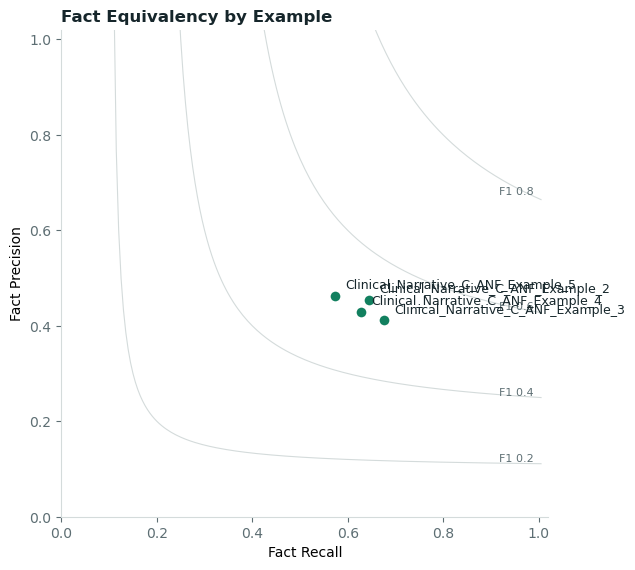

In [14]:
# --- Chart 1: precision-recall scatter with F1 iso-curves ---
import matplotlib.pyplot as plt

INK, MUTED, GRID = "#16262B", "#5D6E73", "#D4DBDB"

fig, ax = plt.subplots(figsize=(6.4, 6.4), facecolor="white")
for f1 in (0.2, 0.4, 0.6, 0.8):                     # reference iso-curves
    r = [x / 200 for x in range(1, 202)]
    p = [f1 * x / (2 * x - f1) if 2 * x > f1 else None for x in r]
    ax.plot(r, p, color=GRID, lw=0.8, zorder=1)
    ax.annotate(f"F1 {f1:.1f}", (0.99, f1 * 0.99 / (2 * 0.99 - f1)),
                color=MUTED, fontsize=8, ha="right", va="bottom", zorder=1)

ax.scatter(hist["fact_recall"], hist["fact_precision"], s=72,
           color="#12805F", edgecolor="white", linewidth=1.5, zorder=3)
for _, r_ in hist.iterrows():                       # direct labels, no legend
    ax.annotate(r_["case"], (r_["fact_recall"], r_["fact_precision"]),
                xytext=(7, 5), textcoords="offset points",
                fontsize=9, color=INK, zorder=4)

ax.set(xlim=(0, 1.02), ylim=(0, 1.02),
       xlabel="Fact Recall",
       ylabel="Fact Precision")
ax.set_title("Fact Equivalency by Example", loc="left",
             color=INK, fontweight="bold")
ax.set_aspect("equal")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRID)
ax.tick_params(colors=MUTED)
plt.tight_layout()
plt.show()

#Fact recall is the share of source facts preserved
#Fact precision is the share of reconstucted facts supported

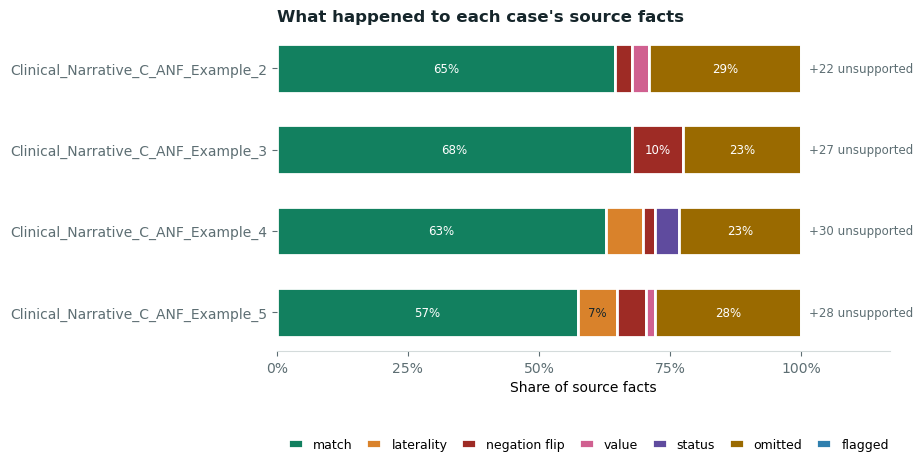

In [15]:
# --- Chart 2: what happened to each case's source facts, fact by fact ---
# Segment palette validated for CVD + normal-vision separation in this order.
FATES = [("matches",               "match",         "#12805F"),
         ("laterality_mismatches", "laterality",    "#D9822B"),
         ("negation_flips",        "negation flip", "#9E2B25"),
         ("value_mismatches",      "value",         "#D06090"),
         ("status_mismatches",     "status",        "#5F4B9E"),
         ("omissions",             "omitted",       "#9A6A00"),
         ("flagged_src",           "flagged",       "#2F7FAE")]

d = hist.copy()
# FLAGGED pairs that carry a source fact = source facts not in any other fate
d["flagged_src"] = (d["source_facts"]
                    - d[[f for f, _, _ in FATES[:-1]]].sum(axis=1)).clip(lower=0)

def label_ink(hexcolor):                            # readable text per segment
    r, g, b = (int(hexcolor[i:i + 2], 16) / 255 for i in (1, 3, 5))
    return "#16262B" if (0.2126 * r + 0.7152 * g + 0.0722 * b) > 0.5 else "white"

fig, ax = plt.subplots(figsize=(9.2, 0.7 * len(d) + 2.1), facecolor="white")
y = range(len(d))
left = pd.Series(0.0, index=d.index)
for col, label, color in FATES:
    frac = d[col] / d["source_facts"]
    ax.barh(y, frac, left=left, height=0.6, color=color, label=label,
            edgecolor="white", linewidth=2)          # 2px surface spacers
    for yi, (f, l) in enumerate(zip(frac, left)):    # label segments >= 7%
        if f >= 0.07:
            ax.annotate(f"{f:.0%}", (l + f / 2, yi), ha="center", va="center",
                        fontsize=8.5, color=label_ink(color))
    left = left + frac
for yi, h in enumerate(d["hallucinations"]):         # recon-side, not a segment
    if h:
        ax.annotate(f"+{int(h)} unsupported", (1.015, yi), va="center",
                    fontsize=8.5, color=MUTED)

ax.set_yticks(list(y), d["case"])
ax.invert_yaxis()
ax.set_xlim(0, 1.17)
ax.set_xticks([0, .25, .5, .75, 1], ["0%", "25%", "50%", "75%", "100%"])
ax.set_xlabel("Share of source facts")
ax.set_title("What happened to each case's source facts", loc="left",
             color=INK, fontweight="bold")
ax.legend(ncol=7, loc="upper left", bbox_to_anchor=(0, -0.18 - 0.22 / len(d)),
          frameon=False, fontsize=9, handlelength=1.2, columnspacing=1.1)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(colors=MUTED)
plt.tight_layout()
plt.show()